In [1]:
import pandas as pd 
import numpy as np

# Loading Dataset

In [2]:
df = pd.read_csv("powerplant_data.csv")

df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
# AT represents temperature in the power plant
# V represents vacuum in the powerplant
# AP represents pressure in the powerplant
# RH represents humidity in the powerplant 

# PE is Produced Energy (output)

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [6]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


# Converting Data into Tensors

In [7]:
# split the data 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [8]:
# Standardize the data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [1]:
import torch 
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32) # can include shuffle if want to.

In [20]:
# for batch size = 32 there will be 299 batches in 1 epoch
# 1 epoch = when our neural network sees entire dataset.

# Defining ANN Model

In [27]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(in_features = X_train.shape[1], out_features = 6), # to calculate weighted sum.
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(in_features = 6, out_features = 6), # to calculate weighted sum.
            nn.ReLU(),
    
            # Output Layer
            nn.Linear(in_features = 6, out_features = 1)  # bcz this is a regression problem.
        )

    def forward(self, x):
        return self.model(x)  # as the sequence is defined in the model so just have to return the output.

In [28]:
# We will built our actual model from our ANN class

import torch.optim as optim

model = ANN() 

# have to define our loss function and optimizers. Loss function is built in our neural network

criterion = nn.MSELoss()   # it defines on the criteria of MSE we try to minimize our Loss fn.

optimizer = optim.Adam(model.parameters())

# Training our ANN model

In [29]:
total_train_loss = []
val_loss = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train() 
    running_loss = 0.0 # total training loss for 1 epoch

    for xb,yb in train_loader:
        # xb is input features for 1 batch
        # yb is output labels for 1 batch
        optimizer.zero_grad() # helps to reset all the values when batch changes.

        outputs = model(xb)  # forward prop....  predicted outputs are computed for a single batch.
        loss = criterion(outputs, yb)  # calculate the loss for a single batch
        loss.backward()  # backward prop.. compute gradients.
        optimizer.step()  # update all the parameters like weight, bias.

        running_loss += loss.item() # here we add .item() bcz loss is a tensor value and we have to convert it to python float.

# we are calculating running loss bcz it will tell us the total loss for 1 epoch and with this we
# calculate the loss for all epoch and we will eventually see the loss minimizing and reach a 
# global minima.

    epoch_train_loss = running_loss/len(train_loader) # total loss for 1 epoch
    total_train_loss.append(epoch_train_loss)  # has loss values of 100 epochs.


    
    # Validation of our neural network on testing data

    model.eval()
    running_val_loss = 0.0  # total validation loss for 1 batch
    
    with torch.no_grad(): # telling pytorch to not calculate gradients as it is back prop....
        
        for xb,yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
    
            running_val_loss += loss.item()
    
        epoch_val_loss = running_val_loss/len(test_loader)
        val_loss.append(epoch_val_loss)

        print(f"{epoch + 1} epoch : training loss is {epoch_train_loss} and validation loss {epoch_val_loss}")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "Best_model.pt") # file saving extensions -> .pt or .pth
            # state_dict is a funtion that tells the model current state values like it's weight or bias.

1 epoch : training loss is 206292.9767578125 and validation loss 205144.5671875
2 epoch : training loss is 201955.57805989584 and validation loss 196144.24921875
3 epoch : training loss is 184064.46842447916 and validation loss 167118.28828125
4 epoch : training loss is 144174.96907552084 and validation loss 118627.53893229166
5 epoch : training loss is 93407.70553385417 and validation loss 69895.17805989583
6 epoch : training loss is 52491.505118815105 and validation loss 38453.9447265625
7 epoch : training loss is 29501.388562011718 and validation loss 22399.79425455729
8 epoch : training loss is 18144.685017903645 and validation loss 14718.63427734375
9 epoch : training loss is 12628.392508951823 and validation loss 10747.399715169271
10 epoch : training loss is 9426.816133626302 and validation loss 8037.293229166667
11 epoch : training loss is 7000.087738037109 and validation loss 5854.930061848959
12 epoch : training loss is 5019.2750376383465 and validation loss 4110.454897054036

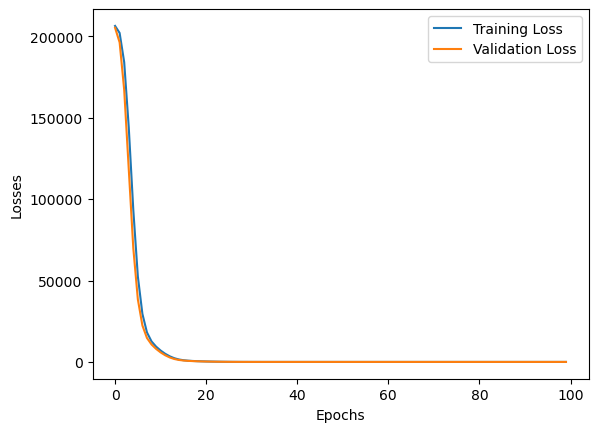

In [30]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": total_train_loss,
    "Validation Loss": val_loss
})


plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [31]:
# how to save the parameters of the best performing epoch(that have minimum training loss)
# So for this we see the validation loss as we want to see how our model perform for unseen data.
# So, model with minimum validation loss is the best model and we want to save that model.
# In the saved model there will be only learnable parameters like weight and bias value.

# Saving and Loading our model

In [32]:
# we save the model in our training part so, the code for saving the best model is in training the model module.

# Loading the best model :

torch.load("Best_model.pt")  #loads the values from the file but it is not give to our model.

model.load_state_dict(torch.load("Best_model.pt")) # this feed the value to our ANN regressor model.

<All keys matched successfully>

# Evaluation

In [36]:
model.eval()
with torch.no_grad():
    train_output = model(X_train_tensor)
    test_output = model(X_test_tensor)

    # Mean Squared Error for training and testing data.
    
    train_mse_loss = criterion(train_output, y_train_tensor)
    test_mse_loss = criterion(test_output, y_test_tensor)

print("Training MSE = ", train_mse_loss.item()) 
print("Testing MSE = ", test_mse_loss.item()) 

Training MSE =  18.672828674316406
Testing MSE =  17.065383911132812


In [38]:
from sklearn.metrics import r2_score

print(f"r2 score is {r2_score(y_test,test_output)}")

r2 score is 0.940360886818379


In [40]:
predicted_df = pd.DataFrame(test_output.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])

pd.concat([predicted_df,actual_df], axis = 1)

,Predicted Values,Actual Values
0,436.698853,433.27
1,436.367340,438.16
2,460.425568,458.42
3,476.392334,480.82
4,438.265839,441.41
...,...,...
1909,449.427368,456.70
1910,433.080078,438.04
1911,467.589691,467.80
1912,432.295624,437.14
